In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Moving Average

In [2]:
config = {
    "task_time": 5,  # Task duration (min)
    "tri_threshold": 4,  # Threshold for detecting stimulation
    "tri_start_point": 2,  # Start point for stimulus detection
    "tri_end_point": 19,  # End point for stimulus detection
    "window_size": 20,  # Moving average window size
}

In [3]:
def load_bin_data(bin_path, config):
    """ Load binary file and extract data and time information """

    num_raw = config["task_time"] * 60 * 1000

    with open(bin_path, "rb") as f:
        raw_data = np.frombuffer(f.read(), dtype=np.float64).reshape(-1, 4)[:num_raw]

    if len(raw_data) != num_raw:
        print(f"Number of data points does not match task duration: {bin_path}")
        return None, None, None, None

    isoTri, greenTri, floData = raw_data[:, :3].T
    original_time = np.arange(1, num_raw + 1) / 1000  # Convert to seconds

    return isoTri, greenTri, floData, original_time

In [4]:
def detect_stimulation_events(signal, config):
    """ Detect stimulation start and end indices based on the threshold """

    threshold = config["tri_threshold"]
    start_point = config["tri_start_point"]
    end_point = config["tri_end_point"]

    logi = np.zeros_like(signal, dtype=int)
    count = 0
    for i, val in enumerate(signal):
        if val >= threshold:
            count += 1
            logi[i] = 1 if start_point < count < end_point else 0
        else:
            count = 0
    start_indices = np.where(np.diff(logi) == 1)[0] + 1
    end_indices = np.where(np.diff(logi) == -1)[0] + 1
    return start_indices, end_indices

In [5]:
def compute_mean_values(start_indices, end_indices, data):
    """ Compute mean values within specified start and end indices """

    return [np.mean(data[start:end]) for start, end in zip(start_indices, end_indices)]


In [6]:
def apply_moving_average(data, config):
    """ Apply moving average to smooth the data """

    window_size = config["window_size"]
    convNum = np.full(window_size, 1/window_size)
    return np.convolve(data, convNum, mode="same")

In [7]:
def process_bin_file(bin_path, config):
    """ Process binary data using multiple functions """

    isoTri, greenTri, floData, original_time = load_bin_data(bin_path, config)
    if isoTri is None:
        return None  # Exit if data is missing

    isoStartInd, isoEndInd = detect_stimulation_events(isoTri, config)
    greenStartInd, greenEndInd = detect_stimulation_events(greenTri, config)

    isoMean = compute_mean_values(isoStartInd, isoEndInd, floData)
    greenMean = compute_mean_values(greenStartInd, greenEndInd, floData)
    greenMeanTime = compute_mean_values(greenStartInd, greenEndInd, original_time)

    min_length = min(len(isoMean), len(greenMean))
    isoMean, greenMean, greenMeanTime = isoMean[:min_length], greenMean[:min_length], greenMeanTime[:min_length]

    isoMovingAve = apply_moving_average(isoMean, config)
    greenMovingAve = apply_moving_average(greenMean, config)

    timeList = np.arange(0.05, 0.05 * (len(isoMovingAve) + 1), 0.05)

    return pd.DataFrame({"time": timeList, "iso": isoMovingAve, "green": greenMovingAve})


In [ ]:
path = # your file path
pathFile = sorted(glob.glob(path)) 

mouse_info = ["mouse1", "mouse2", "mouse3", "mouse4", "mouse5", "mouse6",\
              "mouse7"]

mouse_files = dict(zip(mouse_info, pathFile))
pathFile

['/content/drive/MyDrive/photometry/GRABNE_OFC/Air/NE1_air.bin',
 '/content/drive/MyDrive/photometry/GRABNE_OFC/Air/NE1_batch2_air.bin',
 '/content/drive/MyDrive/photometry/GRABNE_OFC/Air/NE3_batch2_air.bin',
 '/content/drive/MyDrive/photometry/GRABNE_OFC/Air/NE5_air.bin',
 '/content/drive/MyDrive/photometry/GRABNE_OFC/Air/NE5_batch2_air.bin',
 '/content/drive/MyDrive/photometry/GRABNE_OFC/Air/NE6_air.bin',
 '/content/drive/MyDrive/photometry/GRABNE_OFC/Air/NE7_air.bin']

In [9]:
movingAve_dict = {}
for mouse_name, bin_file in mouse_files.items():
    df = process_bin_file(bin_file, config)
    if df is not None:
        movingAve_dict[mouse_name] = df
        print("Done: "+ "{}".format(mouse_name))

Done: mouse1
Done: mouse2
Done: mouse3
Done: mouse4
Done: mouse5
Done: mouse6
Done: mouse7


# dF/F

In [10]:
def idx_of_the_nearest(data, value):
    '''
    Get the index of the nearest value to the given value in the data list/array.

    Parameters:
    data: The list or array of values to search
    value: The value to find the closest match for
    '''
    idx = np.argmin(np.abs(np.array(data) - value))
    return idx

In [11]:
def fig_func(time, iso, green, fittedIso, fittedGeen, isoBCN, greenBCN, dFF_, BC_start, BC_end, BL_start, BL_end, fitting, mouse):
  '''
  Plot the figures for iso, green, dF/F values with baseline correction and fitting

  '''
  plt.figure(figsize=(20, 1))
  plt.subplots_adjust(wspace=0.4, hspace=0.4)

  plt.subplot(1, 3, 1)
  plt.plot(time, iso, color="gray")
  plt.plot(time, green, color="black")

  if fitting == 1:
    plt.plot(time[BC_start:BC_end], green[BC_start:BC_end], color="red")
    plt.plot(time, fittedIso, color="blue")

  if fitting == 1:
    plt.plot(time, fittedGeen, color="blue")
  else:
    plt.plot(time, fittedIso, color="blue")

  plt.title('{}'.format(mouse))

  plt.subplot(1, 3, 2)
  plt.plot(time, isoBCN, color="gray")
  plt.plot(time, greenBCN, color="black")

  plt.subplot(1, 3, 3)
  plt.plot(time, dFF_)
  plt.plot(time[BL_start:BL_end], dFF_[BL_start:BL_end], color='red')

In [12]:
def min_std_func(data):
    data_list = []
    std_list = []

    sec0 = idx_of_the_nearest(time_5min, 0)
    sec60 = idx_of_the_nearest(time_5min, 60)

    for i in range(0, len(data[sec0: sec60]), 1):
        if len(data[sec0: sec60][i:i+200]) == 200:
            data_list.append(data[sec0: sec60][i:i+200])
            std_list.append(np.std(data_list[-1]))
        else:
            pass

    min_std = min(enumerate(std_list), key = lambda x:x[1])[0]
    BL_start = min_std
    BL_end = min_std+200

    return BL_start, BL_end

In [13]:
def dFF_func(time, iso, green, BC_start_sec, BC_end_sec, fitting, mouse):
    '''
    Calculate dF/F for given signals with baseline correction and optional fitting based on 470 or 405.

    Parameters:
    - time: The time points corresponding to the measurement.
    - iso: The isosbestic signal data.
    - green: The fluorescence data from the green channel.
    - BC_start_sec: The start time of the baseline correction period.
    - BC_end_sec: The end time of the baseline correction period.
    - BL_start: The start time for baseline calculation for dF/F.
    - BL_end: The end time for baseline calculation for dF/F.
    - fitting: Flag to choose fitting method (1 for 470, 0 for 405).
    - mouse (str): The identifier or name of the mouse, used for the plot title.
    '''

    min_length = min(len(time), len(iso))
    time, iso, green = time[:min_length], iso[:min_length], green[:min_length]

    BC_start = idx_of_the_nearest(time, BC_start_sec)
    BC_end = idx_of_the_nearest(time, BC_end_sec)

    def baseline_correction(signal):
        fit = np.polyfit(time[BC_start:BC_end], signal[BC_start:BC_end], 1)
        fitted_data = fit[0] * np.array(time) + fit[1]
        return fitted_data

    fittedIso = baseline_correction(iso)
    isoBC = iso - fittedIso
    isoBCN = isoBC + 1

    fittedGreen = baseline_correction(green)
    greenBC = green - fittedGreen if fitting == 1 else green - fittedIso
    greenBCN = greenBC + 1

    dFF = greenBCN / isoBCN
    BL_start, BL_end = min_std_func(dFF)
    BL_mean = np.mean(greenBCN[BL_start:BL_end] / isoBCN[BL_start:BL_end])
    dFF_ = greenBCN / isoBCN - BL_mean

    fig_func(time, iso, green, fittedIso, fittedGreen, isoBCN, greenBCN, dFF_, BC_start, BC_end, BL_start, BL_end, fitting, mouse)

    return dFF_, round(BL_start*0.05, 2), round(BL_end*0.05, 2)

In [14]:
time_5min = [float(_) for _ in np.array(movingAve_dict['mouse1'].filter(like=('time'), axis=1))][10:-9]

/tmp/ipython-input-2875125814.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  time_5min = [float(_) for _ in np.array(movingAve_dict['mouse1'].filter(like=('time'), axis=1))][10:-9]


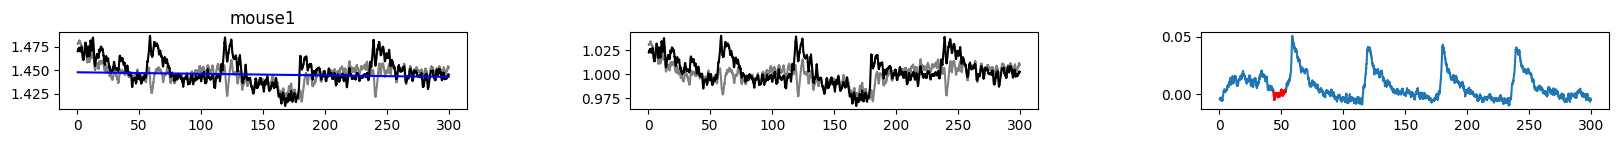

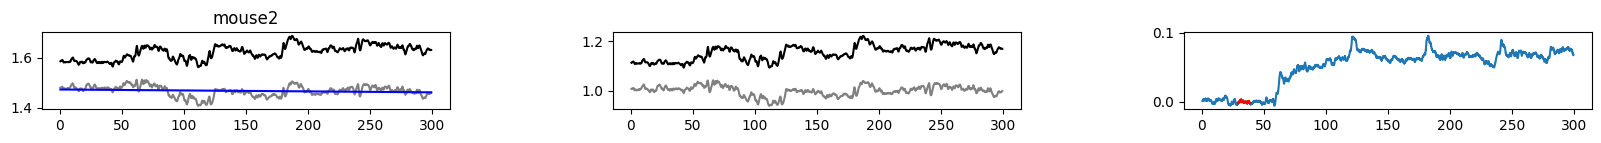

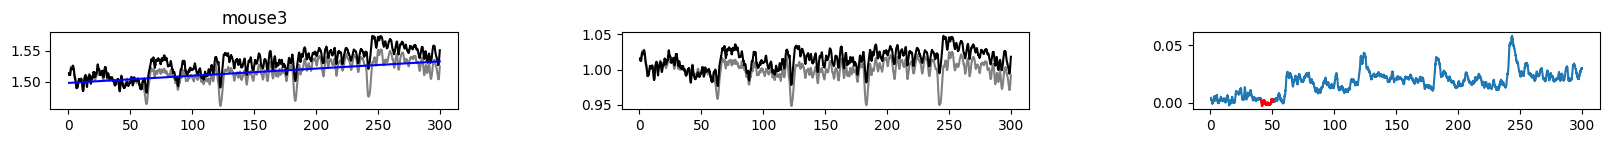

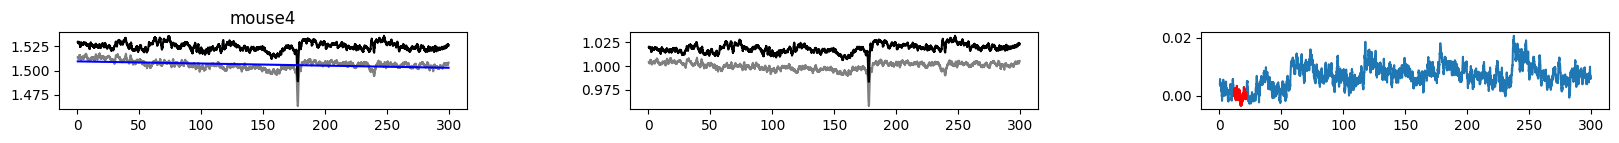

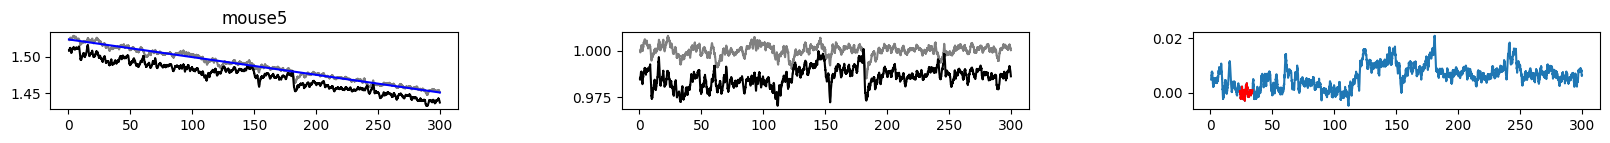

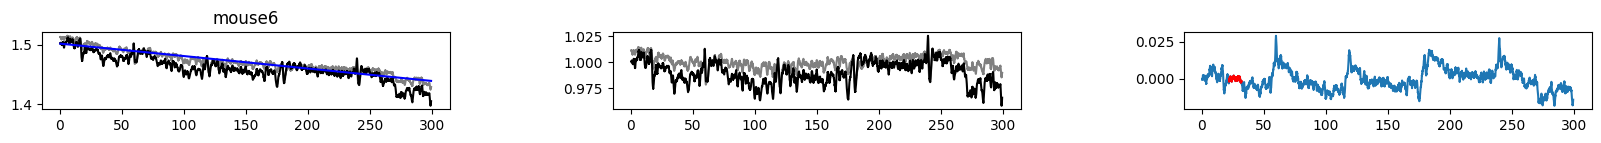

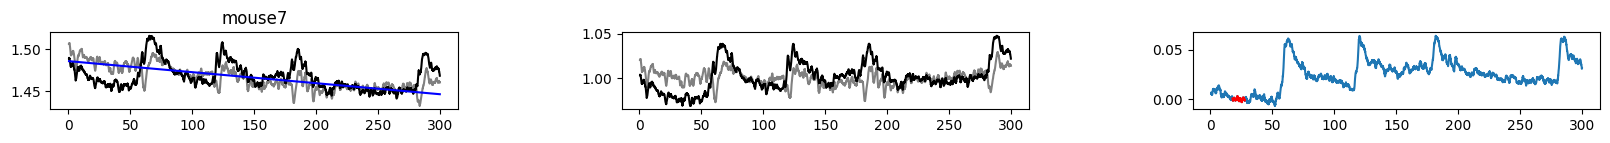

In [15]:
mouse1_dFF, mouse1_BLstart, mouse1_BLend = dFF_func(time_5min, movingAve_dict['mouse1'].iloc[:, 1][10:-9], movingAve_dict['mouse1'].iloc[:, 2][10:-9], 0, 300, 0, "mouse1")
mouse2_dFF, mouse2_BLstart, mouse2_BLend = dFF_func(time_5min, movingAve_dict['mouse2'].iloc[:, 1][10:-9], movingAve_dict['mouse2'].iloc[:, 2][10:-9], 0, 300, 0, "mouse2")
mouse3_dFF, mouse3_BLstart, mouse3_BLend = dFF_func(time_5min, movingAve_dict['mouse3'].iloc[:, 1][10:-9], movingAve_dict['mouse3'].iloc[:, 2][10:-9], 0, 300, 0, "mouse3")
mouse4_dFF, mouse4_BLstart, mouse4_BLend = dFF_func(time_5min, movingAve_dict['mouse4'].iloc[:, 1][10:-9], movingAve_dict['mouse4'].iloc[:, 2][10:-9], 0, 300, 0, "mouse4")
mouse5_dFF, mouse5_BLstart, mouse5_BLend = dFF_func(time_5min, movingAve_dict['mouse5'].iloc[:, 1][10:-9], movingAve_dict['mouse5'].iloc[:, 2][10:-9], 0, 300, 0, "mouse5")
mouse6_dFF, mouse6_BLstart, mouse6_BLend = dFF_func(time_5min, movingAve_dict['mouse6'].iloc[:, 1][10:-9], movingAve_dict['mouse6'].iloc[:, 2][10:-9], 0, 300, 0, "mouse6")
mouse7_dFF, mouse7_BLstart, mouse7_BLend = dFF_func(time_5min, movingAve_dict['mouse7'].iloc[:, 1][10:-9], movingAve_dict['mouse7'].iloc[:, 2][10:-9], 0, 300, 0, "mouse7")

In [16]:
dFF_data = pd.DataFrame([mouse1_dFF, mouse2_dFF, mouse3_dFF, mouse4_dFF, mouse5_dFF, mouse6_dFF, mouse7_dFF]).T
dFF_data.columns = ["mouse1", "mouse2", "mouse3", "mouse4", "mouse5", "mouse6", "mouse7"]
dFF_data.index = time_5min

In [17]:
puff_BLstart = pd.DataFrame([mouse1_BLstart, mouse2_BLstart, mouse3_BLstart, mouse4_BLstart, mouse5_BLstart, mouse6_BLstart, mouse7_BLstart]).T
puff_BLstart.columns = ["mouse1", "mouse2", "mouse3", "mouse4", "mouse5", "mouse6", "mouse7"]

puff_BLend = pd.DataFrame([mouse1_BLend, mouse2_BLend, mouse3_BLend, mouse4_BLend, mouse5_BLend, mouse6_BLend, mouse7_BLend]).T
puff_BLend.columns = ["mouse1", "mouse2", "mouse3", "mouse4", "mouse5", "mouse6", "mouse7"]

# Analyses

## AUC

In [18]:
from sklearn import metrics

In [19]:
def auc_func(data, event_start_ind, event_end_ind, event):
  '''
  calculate Area Under Curve
    - data: Fitted data
    - start: The start time (seconds) for AUC.
    - end: The end time (seconds) for AUC.
  '''
  aucDict = {}
  if event == "BL":
    for i in range(len(data.columns)):
      event_start = idx_of_the_nearest(time_5min, puff_BLstart.iat[0,i])
      event_end = idx_of_the_nearest(time_5min, puff_BLend.iat[0,i])
      signal = list(data.iloc[event_start:event_end,i])
      time = data.iloc[event_start:event_end,i].index

      auc = metrics.auc(time, signal)
      aucDict[data.columns[i]] = float(auc)

    return aucDict

  else:
    for i in range(len(data.columns)):
      signal = list(data.iloc[event_start_ind:event_end_ind,i])
      time = data.iloc[event_start_ind:event_end_ind,i].index

      auc = metrics.auc(time, signal)
      aucDict[data.columns[i]] = float(auc)

  return aucDict

In [20]:
#1st puff
ind_60sec = idx_of_the_nearest(time_5min, 60)
ind_70sec = idx_of_the_nearest(time_5min, 70)

#2nd puff
ind_120sec = idx_of_the_nearest(time_5min, 120)
ind_130sec = idx_of_the_nearest(time_5min, 130)

#3rd puff
ind_180sec = idx_of_the_nearest(time_5min, 180)
ind_190sec = idx_of_the_nearest(time_5min, 190)

In [21]:
puff_BL = auc_func(dFF_data, puff_BLstart, puff_BLend, "BL")
puff_1st = auc_func(dFF_data, ind_60sec, ind_70sec, "1st")
puff_2nd = auc_func(dFF_data, ind_120sec, ind_130sec, "2nd")
puff_3rd = auc_func(dFF_data, ind_180sec, ind_190sec, "3rd")

In [22]:
AUC = pd.DataFrame([puff_BL, puff_1st, puff_2nd, puff_3rd], \
                    index=["BL", "puff_1st", "puff_2nd", "puff_3rd"])

AUC

,mouse1,mouse2,mouse3,mouse4,mouse5,mouse6,mouse7
BL,0.000616,-0.000516,0.000954,0.001180,0.000576,-0.000209,0.001523
puff_1st,0.280851,0.295649,0.202063,0.096584,0.067385,0.107730,0.513345
puff_2nd,0.255372,0.806672,0.327050,0.111083,0.116254,0.050062,0.465391
puff_3rd,0.225547,0.783656,0.291508,0.101919,0.090720,0.133198,0.512918


# Figure